In [ ]:
# 在当前 Jupyter 内核中安装 d2l 教学库。
# %pip 确保安装到当前笔记本绑定的 Python 环境。
# --no-deps 避免重复安装依赖，--quiet 减少输出。
%pip install d2l --no-deps --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 4.4 MB/s eta 0:00:00


In [ ]:
# 数学运算库，后续用于 sqrt(num_hiddens) 缩放嵌入。
import math
# PyTorch 主库，用于张量运算与模型训练。
import torch
# pandas，用于后续整理解码器注意力权重（填充 NaN）。
import pandas as pd
# nn 模块：Linear、Dropout、LayerNorm、Embedding 等网络层。
from torch import nn
# d2l 工具集：多头注意力、位置编码、训练辅助等。
from d2l import torch as d2l

In [ ]:
#@save
class PositionWiseFFN(nn.Module):
    """
    基于位置的前馈网络（Position-wise FFN）。

    Transformer 编码器/解码器块中，注意力层之后紧跟此网络。
    它对序列中每个位置独立地做相同的两层全连接变换：
    FFN(x) = max(0, xW1 + b1)W2 + b2

    参数
    ----
    ffn_num_input : int
        输入特征维度，通常与模型隐藏层维度相同。
    ffn_num_hiddens : int
        中间隐藏层维度，一般是 ffn_num_input 的 2~4 倍。
    ffn_num_outputs : int
        输出维度，通常等于 ffn_num_input，保持形状不变。
    """
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        # 调用父类 nn.Module 的构造函数。
        super(PositionWiseFFN, self).__init__(**kwargs)
        # 第一个线性层：升维至 ffn_num_hiddens。
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        # ReLU 激活函数：引入非线性。
        self.relu = nn.ReLU()
        # 第二个线性层：降维回 ffn_num_outputs。
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        # 输入 X 形状：(batch_size, num_steps, ffn_num_input)
        # 经过两层全连接 + ReLU，输出形状：(batch_size, num_steps, ffn_num_outputs)
        # 每个位置独立变换，不同位置间无交互。
        return self.dense2(self.relu(self.dense1(X)))

In [ ]:
# 构建一个 FFN：输入4维 -> 隐藏4维 -> 输出8维。
ffn = PositionWiseFFN(4, 4, 8)
# 切换评估模式（关闭 Dropout 等训练专用行为）。
ffn.eval()
# 输入形状 (2, 3, 4)：batch=2，序列长=3，特征dim=4。
# 输出取 [0] 即第 0 个样本的结果，形状应为 (3, 8)。
ffn(torch.ones((2, 3, 4)))[0]

tensor([[ 0.4469, -0.3374,  0.4438,  0.2777,  0.2151, -0.3272,  0.7302, -0.1397],
        [ 0.4469, -0.3374,  0.4438,  0.2777,  0.2151, -0.3272,  0.7302, -0.1397],
        [ 0.4469, -0.3374,  0.4438,  0.2777,  0.2151, -0.3272,  0.7302, -0.1397]],
       grad_fn=<SelectBackward0>)

In [ ]:
# 展示 LayerNorm 与 BatchNorm 的区别。

# LayerNorm(2)：对最后一维（大小 2）内归一化，即每条样本内归一化。
ln = nn.LayerNorm(2)

# BatchNorm1d(2)：对每个特征维度跨样本归一化，即跨样本归一化。
bn = nn.BatchNorm1d(2)

# 输入 X 形状 (2, 2)：2 个样本，每个样本 2 个特征。
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)

# 在训练模式下比较两种归一化的计算结果。
# LayerNorm 对每个样本内的特征求均值和方差；
# BatchNorm 对跨样本的每个特征求均值和方差。
print('layer norm:', ln(X), '\nbatch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [ ]:
#@save
class AddNorm(nn.Module):
    """
    残差连接（Add）+ 层归一化（Layer Norm）。

    Transformer 中每个子层后都会接这个模块，有两个作用：
    1. 残差连接 (X + Y)：缓解梯度消失，让信息流更顺畅。
    2. 层归一化：稳定训练，加速收敛。

    参数
    ----
    normalized_shape : int | list[int]
        LayerNorm 范围（通常是最后 1~2 维）。
    dropout : float
        对子层输出 Y 应用 Dropout，增强正则化。
    """
    def __init__(self, normalized_shape, dropout, **kwargs):
        # 调用父类构造。
        super(AddNorm, self).__init__(**kwargs)
        # Dropout 层：对子层输出做随机丢布。
        self.dropout = nn.Dropout(dropout)
        # 层归一化层。
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        # X：该子层的原始输入（残差连接用）。
        # Y：该子层的输出，先经 Dropout，再与 X 相加，最后层归一化。
        return self.ln(self.dropout(Y) + X)

In [ ]:
# 构建 AddNorm：normalized_shape=[3, 4] 表示对最后两维归一化。
add_norm = AddNorm([3, 4], 0.5)
# 切换评估模式。
add_norm.eval()
# 测验输出形状与输入一致：(batch=2, seq_len=3, features=4)。
add_norm(torch.ones((2, 3, 4)), torch.ones((2, 3, 4))).shape

torch.Size([2, 3, 4])

In [ ]:
#@save
class EncoderBlock(nn.Module):
    """
    Transformer 编码器块，包含：
    1. 多头自注意力（self-attention）
    2. 加性残差 + 层归一化（AddNorm）
    3. 加性前馈网络（PositionWiseFFN）
    4. 加性残差 + 层归一化（AddNorm）
    """
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        # 调用父类构造。
        super(EncoderBlock, self).__init__(**kwargs)
        # 多头注意力层（自注意力：Q=K=V=输入 X）。
        self.attention = d2l.MultiHeadAttention(
            num_hiddens, num_heads, dropout, use_bias)
        # 第一个 AddNorm：接在自注意力层后。
        self.addnorm1 = AddNorm(norm_shape, dropout)
        # 前馈网络层：ffn_num_input -> ffn_num_hiddens -> num_hiddens。
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        # 第二个 AddNorm：接在 FFN 层后。
        self.addnorm2 = AddNorm(norm_shape, dropout)

    # X 形状：(batch_size, num_steps, num_hiddens)
    # valid_lens：(batch_size,)，用于注意力掩码。
    def forward(self, X, valid_lens):
        # 第一子层：自注意力 + 残差 + 层归一化。
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        # 第二子层：FFN + 残差 + 层归一化。
        return self.addnorm2(Y, self.ffn(Y))

In [ ]:
# 构建一个编码器块并验证输出形状。
# 输入 X 形状：(batch=2, num_steps=100, num_hiddens=24)。
X = torch.ones((2, 100, 24))
# 有效序列长度：第 0 个样本有效长 3，第 1 个样本有效长 2。
valid_lens = torch.tensor([3, 2])
# key/query/value 维度=24，num_hiddens=24，
# norm_shape=[100,24]，ffn输入=24、隐藏=48，num_heads=8，dropout=0.5。
encoder_blk = EncoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5)
encoder_blk.eval()
# 输出形状应与输入相同：(2, 100, 24)。
encoder_blk(X, valid_lens).shape

torch.Size([2, 100, 24])

In [ ]:
#@save
class TransformerEncoder(d2l.Encoder):
    """
    Transformer 编码器，由 num_layers 个 EncoderBlock 堆叠而成。
    """
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        # 调用父类构造。
        super(TransformerEncoder, self).__init__(**kwargs)
        # 保存隐藏层维度，嵌入缩放时会用到。
        self.num_hiddens = num_hiddens
        # 词嵌入层：token id -> num_hiddens 维向量。
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        # 位置编码层：给嵌入加上位置信息。
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        # 用 Sequential 容纳 num_layers 个 EncoderBlock。
        self.blks = nn.Sequential()
        for i in range(num_layers):
            # 每层用字符串命名，方便调试时识别。
            self.blks.add_module("block" + str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        # 显式占位，表示嘿年忽略额外参数（用于兼容不同调用签名）。
        _ = args
        # 嵌入层输出乘以 sqrt(num_hiddens) 进行缩放。
        # 目的：让嵌入层输出的模较与位置编码层输出等阶，避免一层压坠另一层。
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        # 初始化用于存储各层注意力权重的列表，共 num_layers 个元素。
        self.attention_weights = [None] * len(self.blks)
        # 逐层前向传播，并存储每层的注意力权重。
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            # attention -> d2l.MultiHeadAttention -> attention -> DotProductAttention -> attention_weights
            self.attention_weights[i] = blk.attention.attention.attention_weights
        # 输出最终编码结果，形状：(batch_size, num_steps, num_hiddens)。
        return X

In [ ]:
# 构建编码器并验证输出形状。
# vocab_size=200，各种 size=24，隐藏层=24，
# norm_shape=[100,24]，ffn输入=24、隐藏=48，头数=8，层数=2，dropout=0.5。
encoder = TransformerEncoder(
    200, 24, 24, 24, 24, [100, 24], 24, 48, 8, 2, 0.5)
encoder.eval()
# 输入：(batch=2, num_steps=100) 的 token id 序列。
# 应输出: (2, 100, 24)。
encoder(torch.ones((2, 100), dtype=torch.long), valid_lens).shape

torch.Size([2, 100, 24])

In [ ]:
class DecoderBlock(nn.Module):
    """
    Transformer 解码器中第 i 个块。

    包含三个子层：
    1. 掩码多头自注意力（训练时使用因果掩码防 leak）。
    2. 编码器-解码器交叉注意力（将编码器输出作为 K/V）。
    3. 前馈网络。
    每个子层后接 AddNorm。
    """
    # i 表示这是第几层解码器块，用于如变黊缓存管理。
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        # 调用父类构造。
        super(DecoderBlock, self).__init__(**kwargs)
        # 记录层索引，用于训练时分层索引 state[2][self.i]。
        self.i = i
        # 第一个自注意力（掩码）。
        self.attention1 = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout)
        # 第一个 AddNorm。
        self.addnorm1 = AddNorm(norm_shape, dropout)
        # 第二个多头注意力：交叉注意力，Q=解码器，K=V=编码器输出。
        self.attention2 = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout)
        # 第二个 AddNorm。
        self.addnorm2 = AddNorm(norm_shape, dropout)
        # 前馈网络层。
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        # 第三个 AddNorm。
        self.addnorm3 = AddNorm(norm_shape, dropout)

    # X：解码器输入，(batch_size, num_steps, num_hiddens)。
    # state = [enc_outputs, enc_valid_lens, [None/key_cache per layer]]
    def forward(self, X, state):
        # 取出编码器输出和源序列有效长度。
        enc_outputs, enc_valid_lens = state[0], state[1]

        # 训练阶段：state[2][self.i] 初始为 None，起始时 key_values = 该层全序列。
        # 预测阶段：state[2][self.i] 已包含历史解码展现，此时拼接当前词元。
        if state[2][self.i] is None:
            key_values = X
        else:
            # 将历史撨语与当前 step 在序列维连接。
            key_values = torch.cat((state[2][self.i], X), axis=1)
        # 更新该层的 key/value 缓存。
        state[2][self.i] = key_values

        if self.training:
            batch_size, num_steps, _ = X.shape
            # 训练时构造因果掩码的 valid_lens：
            # 第 i 个位置只能看到第 1~i 个 token，
            # 形状 (batch_size, num_steps)，每行为 [1, 2, ..., num_steps]。
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            # 预测时每次只输入一个 token，不需要掩码。
            dec_valid_lens = None

        # 第一子层：掩码自注意力。
        # Q=K=V=解码器输入（包含历史缓存）。
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)

        # 第二子层：编码器-解码器交叉注意力。
        # Q=解码器中间层输出 Y，K=V=编码器输出 enc_outputs。
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)

        # 第三子层：FFN + AddNorm，返回输出和更新后的 state。
        return self.addnorm3(Z, self.ffn(Z)), state

In [ ]:
# 构建解码器块（第 0 层）并验证形状。
decoder_blk = DecoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5, 0)
decoder_blk.eval()
# 构造输入 X：(batch=2, num_steps=100, num_hiddens=24)。
X = torch.ones((2, 100, 24))
# 构造 state：[enc_outputs, enc_valid_lens, [None]]。
# enc_outputs 由 encoder_blk 初闭。
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
# 输出形状应与输入相同：(2, 100, 24)。
decoder_blk(X, state)[0].shape

torch.Size([2, 100, 24])

In [ ]:
class TransformerDecoder(d2l.AttentionDecoder):
    """
    Transformer 解码器，由 num_layers 个 DecoderBlock 堆叠而成。
    """
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        # 调用父类构造。
        super(TransformerDecoder, self).__init__(**kwargs)
        # 保存隐藏层维度和层数。
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        # 词嵌入层。
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        # 位置编码层。
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        # 用 Sequential 容纳 num_layers 个 DecoderBlock。
        self.blks = nn.Sequential()
        for i in range(num_layers):
            # 第 i 层的解码器块。
            self.blks.add_module("block" + str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, i))
        # 输出线性层：把 num_hiddens 维映射到目标词表大小，得到 logits。
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        # 显式占位，表示有意忽略额外参数（用于兼容不同调用签名）。
        _ = args
        # 初始化解码器状态列表：
        # [0] 编码器输出 enc_outputs
        # [1] 源序列有效长度 enc_valid_lens
        # [2] 每层 DecoderBlock 的 key/value 缓存，初始为 None
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        # 嵌入 + 缩放 + 位置编码。
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        # 初始化注意力权重存储列表：
        # _attention_weights[0][i] -> 第 i 层解码器自注意力。
        # _attention_weights[1][i] -> 第 i 层编码器-解码器交叉注意力。
        self._attention_weights = [[None] * len(self.blks) for _ in range(2)]
        for i, blk in enumerate(self.blks):
            # 逐层前向传播，state 在各层间传递并更新。
            X, state = blk(X, state)
            # 存储第 i 层解码器自注意力权重。
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            # 存储第 i 层编码器-解码器交叉注意力权重。
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights
        # 输出层映射到词表 logits。返回 (batch_size, num_steps, vocab_size) 与 state。
        return self.dense(X), state

    @property
    def attention_weights(self):
        # 对外暴露注意力权重，训练完成后可视化。
        return self._attention_weights

In [20]:
# 说明：不同 d2l 版本中，net(...) 的返回格式可能不同（有的直接返回张量，有的返回元组）。
# 这里自定义一个兼容训练函数，确保都能训练。
def train_seq2seq_compat(net, data_iter, lr, num_epochs, tgt_vocab, device):
    # 定义参数初始化函数（Xavier 初始化），常用于提升 RNN 训练稳定性。
    def xavier_init_weights(m):
        # 线性层权重用 Xavier 均匀分布初始化。
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        # GRU 中多个内部权重矩阵也做 Xavier 初始化。
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    # 对整个网络递归应用初始化。
    net.apply(xavier_init_weights)
    # 把模型放到计算设备。
    net.to(device)

    # 使用 Adam 优化器。
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    # 使用“带掩码”的交叉熵损失，忽略 padding 位置。
    loss = d2l.MaskedSoftmaxCELoss()

    # 切换到训练模式（启用 Dropout 等）。
    net.train()

    # 用于可视化训练损失。
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[10, num_epochs])

    # 外层循环：遍历 epoch。
    for epoch in range(num_epochs):
        # 计时器，用于统计 tokens/sec。
        timer = d2l.Timer()
        # metric[0] 累计总损失，metric[1] 累计 token 数。
        metric = d2l.Accumulator(2)

        # 内层循环：遍历每个 batch。
        for batch in data_iter:
            # 清空历史梯度。
            optimizer.zero_grad()

            # batch 包含：源句子 X、源有效长度、目标句子 Y、目标有效长度。
            # 并统一移动到 device 上。
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]

            # 构造解码器输入：第一个 token 是 <bos>（句子开始符）。
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                               device=device).reshape(-1, 1)

            # Teacher forcing：把目标序列右移一位作为解码器输入。
            # dec_input 形状 (batch_size, num_steps)。
            dec_input = d2l.concat([bos, Y[:, :-1]], 1)

            # 前向传播：预测目标序列每个位置的词分布。
            Y_hat = net(X, dec_input, X_valid_len)

            # 兼容处理：若返回 (Y_hat, state) 之类结构，只取预测张量。
            if isinstance(Y_hat, (tuple, list)):
                Y_hat = Y_hat[0]

            # 计算每个样本每个时间步的损失（内部会根据 Y_valid_len 做 mask）。
            l = loss(Y_hat, Y, Y_valid_len)

            # 反向传播（对 batch 内所有有效 token 损失求和）。
            l.sum().backward()

            # 梯度裁剪，防止 RNN 梯度爆炸。阈值设为 1。
            d2l.grad_clipping(net, 1)

            # 统计当前 batch 的有效 token 总数。
            num_tokens = Y_valid_len.sum()

            # 更新模型参数。
            optimizer.step()

            # 不跟踪梯度地更新统计量。
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)

        # 每 10 个 epoch 记录一次平均 token 损失。
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))

    # 打印最终损失与吞吐率。
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
          f'tokens/sec on {str(device)}')

loss 0.028, 8077.1 tokens/sec on cuda:0


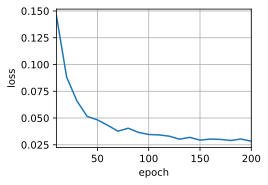

In [ ]:
# ===== 训练超参数配置 =====
# 模型隐藏维度、层数、Dropout、批大小、序列长度。
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
# 学习率、训练轮数、设备（自动选 GPU/CPU）。
lr, num_epochs, device = 0.005, 200, d2l.try_gpu()
# FFN 输入维度、FFN 隐藏维度、注意力头数。
ffn_num_input, ffn_num_hiddens, num_heads = 32, 64, 4
# Q、K、V 各自的维度。
key_size, query_size, value_size = 32, 32, 32
# LayerNorm 应用的维度：单小子元素维度=32。
norm_shape = [32]

# 加载机器翻译数据（英语 -> 法语）。
train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

# 构建 Transformer 编码器。
encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)

# 构建 Transformer 解码器。
decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)

# 组装成完整的 Encoder-Decoder 模型。
net = d2l.EncoderDecoder(encoder, decoder)

# 启动训练。
train_seq2seq_compat(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [ ]:
# ===== 用训练好的模型翻译并计算 BLEU =====

# 测试英语句子。
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']

# 对应参考法语。
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']

for eng, fra in zip(engs, fras):
    # predict_seq2seq 第六个参数 True 表示返回解码器各步的注意力权重序列。
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    # 输出翻译结果和 2-gram BLEU 分，越接近 1 越好。
    print(f'{eng} => {translation}, ',
          f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est calme .,  bleu 1.000
i'm home . => je suis chez moi .,  bleu 1.000


In [ ]:
# 整理编码器各层各头的注意力权重。
# net.encoder.attention_weights 是一个长度为 num_layers 的列表，
# 每个元素是形状 (batch_size*num_heads, num_queries, num_keys) 的注意力权重。
# torch.cat 将所有层在第 0 维拼接。
# reshape 整理为 (num_layers, num_heads, num_queries, num_steps)。
enc_attention_weights = torch.cat(net.encoder.attention_weights, 0).reshape(
    (num_layers, num_heads, -1, num_steps))
enc_attention_weights.shape

torch.Size([2, 4, 10, 10])

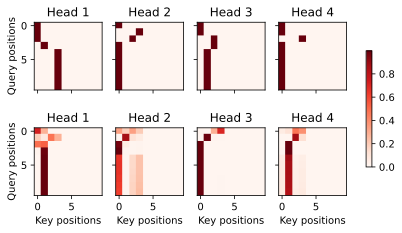

In [ ]:
# 可视化编码器各层各头的注意力热力图。
# titles 中列出 Head 1 ~ Head 4（此处 num_heads=4）。
d2l.show_heatmaps(
    enc_attention_weights.cpu(),
    xlabel='Key positions',
    ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))

In [ ]:
# ===== 整理解码器注意力权重 =====

# dec_attention_weight_seq 中每个 step 保存了两种注意力（自注意力、交叉注意力），
# 每种包含 num_layers 个层、每层 num_heads 个头。
# 这里采用列表推导式把所有 step 的注意力权重展平成二维列表。
# [0]层级对应小批概率第 0 个样本、第 0 个层系、第 0 个头。
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weight_seq
                            for attn in step for blk in attn for head in blk]

# pandas 填充 NaN：不同 step 输出序列长度不同，用 0 填充届不足的位置。
dec_attention_weights_filled = torch.tensor(
    pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)

# reshape 成 (num_steps, 2, num_layers, num_heads, seq_len)。
# 2 弹算自注意力与交叉注意力。
dec_attention_weights = dec_attention_weights_filled.reshape(
    (-1, 2, num_layers, num_heads, num_steps))

# permute 把 dim 1（注意力类型）移到第 0 位，方便分别取出。
# dec_self_attention_weights：解码器自注意力。
# dec_inter_attention_weights：解码器与编码器的交叉注意力。
dec_self_attention_weights, dec_inter_attention_weights = \
    dec_attention_weights.permute(1, 2, 3, 0, 4)
dec_self_attention_weights.shape, dec_inter_attention_weights.shape

(torch.Size([2, 4, 6, 10]), torch.Size([2, 4, 6, 10]))

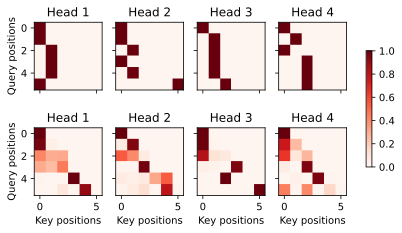

In [ ]:
# 可视化解码器自注意力权重。
# 只口翻译序列实际长度（加上 <eos>）擐对应的 key 倒点资。
# +1 是为了包含句子开始符（<bos>）。
d2l.show_heatmaps(
    dec_self_attention_weights[:, :, :, :len(translation.split()) + 1],
    xlabel='Key positions', ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)], figsize=(7, 3.5))

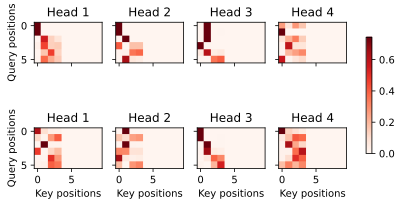

In [ ]:
# 可视化解码器与编码器的交叉注意力权重。
# x 轴是编码器的 key 位置（源序列），y 轴是解码器的 query 位置（目标序列）。
d2l.show_heatmaps(
    dec_inter_attention_weights,
    xlabel='Key positions',
    ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))